In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

/home/deve/myenv/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


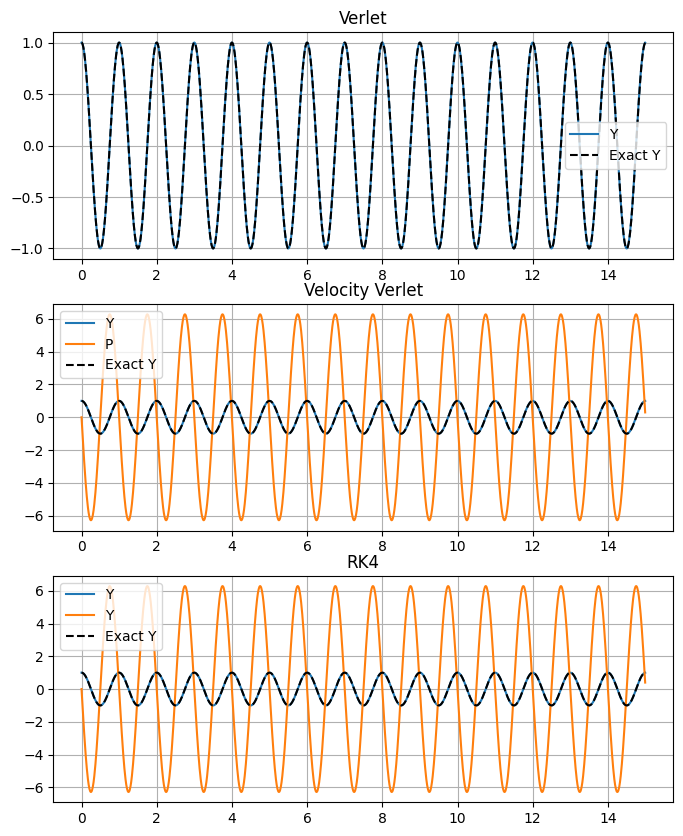

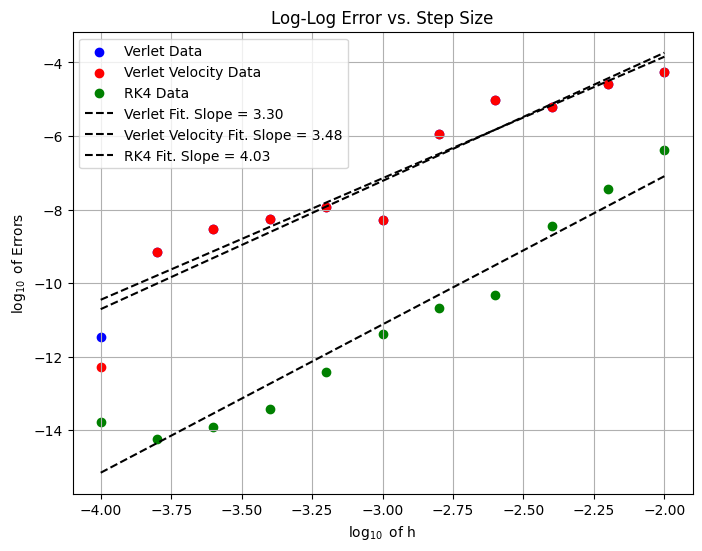

In [2]:
#Q1

#functions 
def f(x, y): #acceleration function
    return -(4*np.pi**2) *y

def g(x,y):  #derivative function for euler and rk4
    return np.asarray([y[1], -4*(np.pi**2)*y[0]])

def euler(f, x, y, h):
    return y + h * f(x, y)

def verlet(f1, x, yn, ynm1, h):
    return 2*yn - ynm1 + f1(x, yn)*(h**2)

def velocity_verlet(f1, x, yn, vn, h):
    ynp1 = yn + vn*h + 0.5*f1(x, yn)*(h**2)
    vnp1 = vn + 0.5*(f1(x, yn) + f1(x + h, ynp1))*h
    return ynp1, vnp1

def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h/2, y + k1/2)
    k3 = h * f1(x + h/2, y + k2/2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2*k2 + 2*k3 + k4)/6

def caller_y(method, fn, y0, v0, N, xs, h):
    ys = np.zeros(N)
    ys[0] = y0
    x0 = xs[0]
    ys[1] = y0 + v0*h + 0.5*fn(x0, y0)*(h**2) 
    for i in range(2, N):
        x = xs[i]
        ys[i] = method(fn, x, ys[i-1], ys[i-2], h)
    
    return ys


def caller_yv(method, fn, y0, v0, N, xs, h):
    
    ys = np.zeros(N)
    vs = np.zeros(N)
    ys[0] = y0
    vs[0] = v0
    for i in range(1, N):
        x = xs[i]
        ys[i], vs[i] = method(fn, x, ys[i-1], vs[i-1], h)
    
    return ys, vs

def caller_rk(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

h = 1.0e-2
x0 = 0.0
xf = 15

xs = np.arange(x0, xf, h)
N = len(xs)

y_ini = np.asarray([1.0, 0])  # Initial condition 
p_ini = np.asarray([0])

# Call the methods
y_v = caller_y(verlet, f, y_ini[0],p_ini[0], N, xs, h)
y_vv, p_vv = caller_yv(velocity_verlet, f, y_ini[0],p_ini[0], N, xs, h)
y_rk4 = caller_rk(rk4, g, y_ini, N, xs, h)

# Plot for Velocity method
plt.figure(figsize=(8, 10))
y_exact = np.cos(2*np.pi*xs)
plt.subplot(3, 1, 1)
plt.plot(xs, y_v, label="Y")
plt.plot(xs,y_exact, label = "Exact Y", ls = "--", color = "k")
plt.title("Verlet")
plt.legend()
plt.grid()

# Plot for Velocity Verlet method
plt.subplot(3, 1, 2)
plt.plot(xs, y_vv, label="Y")
plt.plot(xs, p_vv, label="P")
plt.plot(xs,y_exact, label = "Exact Y", ls = "--", color = "k")
plt.title("Velocity Verlet")
plt.legend()
plt.grid()

# Plot for RK4 method
plt.subplot(3, 1, 3)
plt.plot(xs, y_rk4, label="Y")
plt.plot(xs,y_exact, label = "Exact Y", ls = "--", color = "k")
plt.title("RK4")
plt.legend()
plt.grid()


# Define the range for h
hs = 10.0 ** np.arange(-4.0, -2.0 + 0.2, 0.2)


# Calculate errors of position
errors_v = np.zeros(len(hs))
errors_vv = np.zeros(len(hs))
errors_rk4 = np.zeros(len(hs))
for i, h in enumerate(hs):
    xs = np.arange(x0, 10.0 + h, h)  
    N = len(xs)
    y_exact = np.cos(2*np.pi*xs) 
    y_v = caller_y(verlet, f, y_ini[0],p_ini[0], N, xs, h)
    y_vv, p_vv = caller_yv(velocity_verlet, f, y_ini[0],p_ini[0], N, xs, h)
    y_rk4 = caller_rk(rk4, g, y_ini, N, xs, h)
    errors_v[i] = abs(y_v[-1] - y_exact[-1])
    errors_vv[i] = abs(y_vv[-1] - y_exact[-1])
    errors_rk4[i] = abs(y_rk4[-1, 0] - y_exact[-1])

# Error data in log-log format
xd = np.log10(hs)
yd_v = np.log10(errors_v)
yd_vv = np.log10(errors_vv)
yd_rk4 = np.log10(errors_rk4)

# Define the fitting function
def line(x, m, c):
    return x*m + c

# Fit the data
popt_v, _  = curve_fit(line, xd, yd_v, p0=[1.0, 1.0])
popt_vv, _  = curve_fit(line, xd, yd_vv, p0=[1.0, 1.0])
popt_rk4, _  = curve_fit(line, xd, yd_rk4, p0=[1.0, 1.0])

# Generate smooth fit
xfine = np.linspace(xd[0], xd[-1], 1000)
yfine_v = line(xfine, *popt_v)
yfine_vv = line(xfine, *popt_vv)
yfine_rk4 = line(xfine, *popt_rk4)

# Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.scatter(xd, yd_v, color = "blue", label="Verlet Data")
plt.scatter(xd, yd_vv, color = "red", label="Verlet Velocity Data")
plt.scatter(xd, yd_rk4, color = "green", label="RK4 Data")
plt.plot(xfine, yfine_v, label=f"Verlet Fit. Slope = {popt_v[0]:.2f}", color="k", ls = "--")
plt.plot(xfine, yfine_vv, label=f"Verlet Velocity Fit. Slope = {popt_vv[0]:.2f}", color="k", ls = "--")
plt.plot(xfine, yfine_rk4, label=f"RK4 Fit. Slope = {popt_rk4[0]:.2f}", color="k", ls = "--")
plt.xlabel(r"$\log_{10}$ of h")
plt.ylabel(r"$\log_{10}$ of Errors")
plt.grid()
plt.legend()
plt.title("Log-Log Error vs. Step Size")
plt.show()

# Q2
The euqations of motions are as follows:
In the y-direction:
F = ma
ma_y = -mg -v_y*gamma
therfore a_y = dv_y/dt = -g -v_y*gamma/m

In the x-direction:
F = ma
ma_x = -v_x*gamma
therfore a_x = dv_x/dt = -v_x*gamma/m

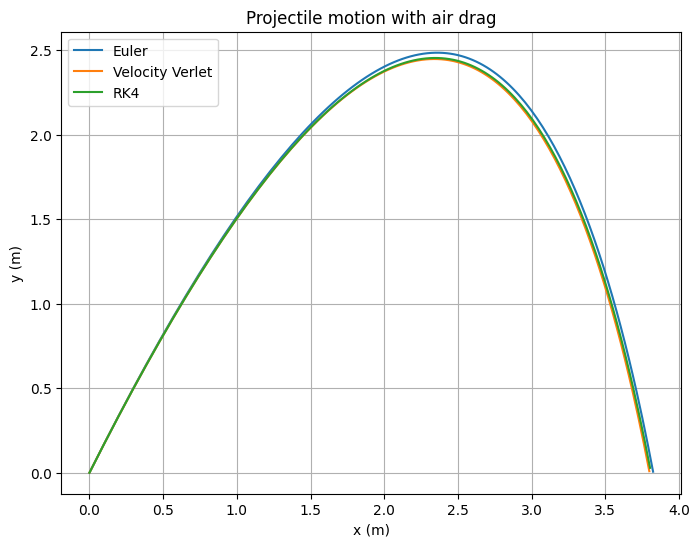

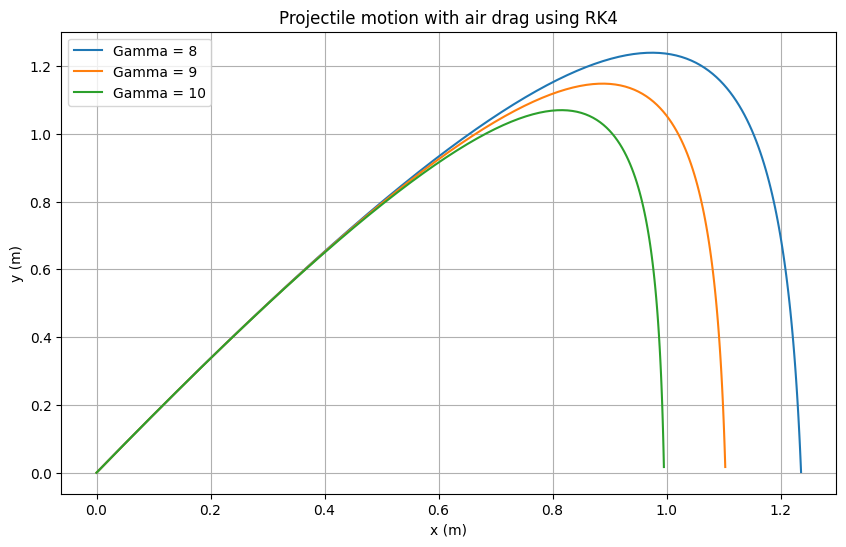

In [21]:
#Q2
grav = -9.8
gamma = 2
mass = 2

def f(t, Y): #derivative function
    x, y, vx, vy = Y
    return np.array([vx, vy, -vx*gamma/mass, grav - vy*gamma/mass])

x0 = 0
y0 = 0
vx0 = 5
vy0 = 5*np.sqrt(3)   # 10*sin(60°)

Y0 = np.array([x0, y0, vx0, vy0])

h = 0.01
tmax = 5.0   

def acc(vx, vy):
    ax = -vx*gamma/mass
    ay =  grav - vy*gamma/mass
    return ax,ay

def euler_step(f, t, y, h):
    return y + h*f(t,y)

def velocity_verlet_step(x, y, vx, vy, h):
    ax, ay = acc(vx, vy)

    x_new = x + vx*h + 0.5*ax*h*h
    y_new = y + vy*h + 0.5*ay*h*h

    vx_half = vx + 0.5*ax*h
    vy_half = vy + 0.5*ay*h

    ax_new, ay_new = acc(vx_half, vy_half)

    vx_new = vx_half + 0.5*ax_new*h
    vy_new = vy_half + 0.5*ay_new*h

    return x_new, y_new, vx_new, vy_new


def rk4_step(f, t, y, h):
    k1 = h*f(t,y)
    k2 = h*f(t+h/2, y+k1/2)
    k3 = h*f(t+h/2, y+k2/2)
    k4 = h*f(t+h, y+k3)
    return y + (k1 + 2*k2 + 2*k3 + k4)/6


def integrate(method):
    t = 0
    Y = Y0.copy()
    xs, ys = [], []

    while Y[1] >= 0:
        xs.append(Y[0])
        ys.append(Y[1])

        if method == "euler":
            Y = euler_step(f, t, Y, h)
        elif method == "rk4":
            Y = rk4_step(f, t, Y, h)
        elif method == "velocity_verlet":
            x,y,vx,vy = Y
            x,y,vx,vy = velocity_verlet_step(x,y,vx,vy,h)
            Y = np.array([x,y,vx,vy])
        t += h

    return np.array(xs), np.array(ys)

xe, ye = integrate("euler")
xv, yv = integrate("velocity_verlet")
xr, yr = integrate("rk4")
plt.figure(figsize=(8,6))
plt.plot(xe, ye, label="Euler")
plt.plot(xv, yv, label="Velocity Verlet")
plt.plot(xr, yr, label="RK4")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Projectile motion with air drag")
plt.legend()
plt.grid()
plt.show()

gamma_vals = np.arange(8,11)
fig,ax = plt.subplots(figsize = (10,6))
for gamma_val in gamma_vals:
    gamma = gamma_val
    xr, yr = integrate("rk4")
    ax.plot(xr, yr, label=f"Gamma = {gamma}")
    plt.legend()
plt.grid()
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Projectile motion with air drag using RK4")
plt.show()


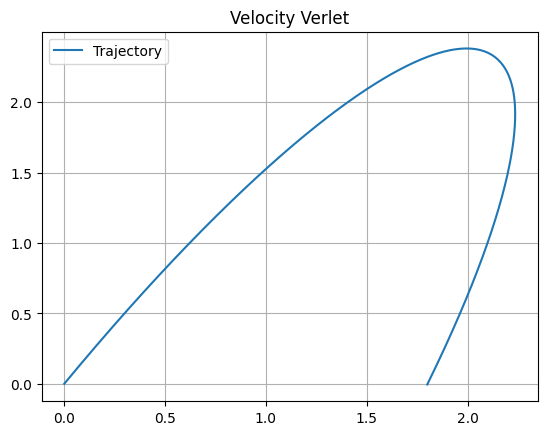

In [5]:
#functions 
grav = -9.8
gamma = 10
mass = 2

def x_derivative(t, X): #derivative function
    x, vx = X
    return np.array([vx, -vx*gamma/mass])

def y_derivative(t, Y): #derivative function
    y,vy = Y
    return np.array([vy, grav - vy*gamma/mass])

x0 = 0
y0 = 0
vx0 = 5
vy0 = 5*np.sqrt(3)   # 10*sin(60°)

Y0 = np.array([x0, y0, vx0, vy0])

h = 0.0001
tmax = 5.0 

def x_acc(t, vx):
    ax = -vx*gamma/mass
    return ax

def y_acc(t, vy):
    ay =  grav - vy*gamma/mass
    return ay



def velocity_verlet(f1, x, yn, vn, h):
    ynp1 = yn + vn*h + 0.5*f1(x, yn)*(h**2)
    vnp1 = vn + 0.5*(f1(x, yn) + f1(x + h, ynp1))*h
    return ynp1, vnp1


def caller_yv(method, fn, y0, v0, N, xs, h):
    
    ys = np.zeros(N)
    vs = np.zeros(N)
    ys[0] = y0
    vs[0] = v0
    for i in range(1, N):
        x = xs[i]
        ys[i], vs[i] = method(fn, x, ys[i-1], vs[i-1], h)
    
    return ys, vs
t0 = 0
tf = 5
ts = np.arange(t0, tf, h)
N = len(ts)


# Call the methods
x_vv, vx_vv = caller_yv(velocity_verlet, x_acc, x0,vx0, N, ts, h)
y_vv, vy_vv = caller_yv(velocity_verlet, y_acc, y0,vy0, N, ts, h)

# Plot for Velocity Verlet method
i = 0
x_f = []
y_f = []
while y_vv[i]>=-0.005:
    x_f.append(x_vv[i])
    y_f.append(y_vv[i])
    i+=1
plt.plot(x_f, y_f, label = "Trajectory")
plt.title("Velocity Verlet")
plt.legend()
plt.grid()
plt.show()
